C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10080\4011792460.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


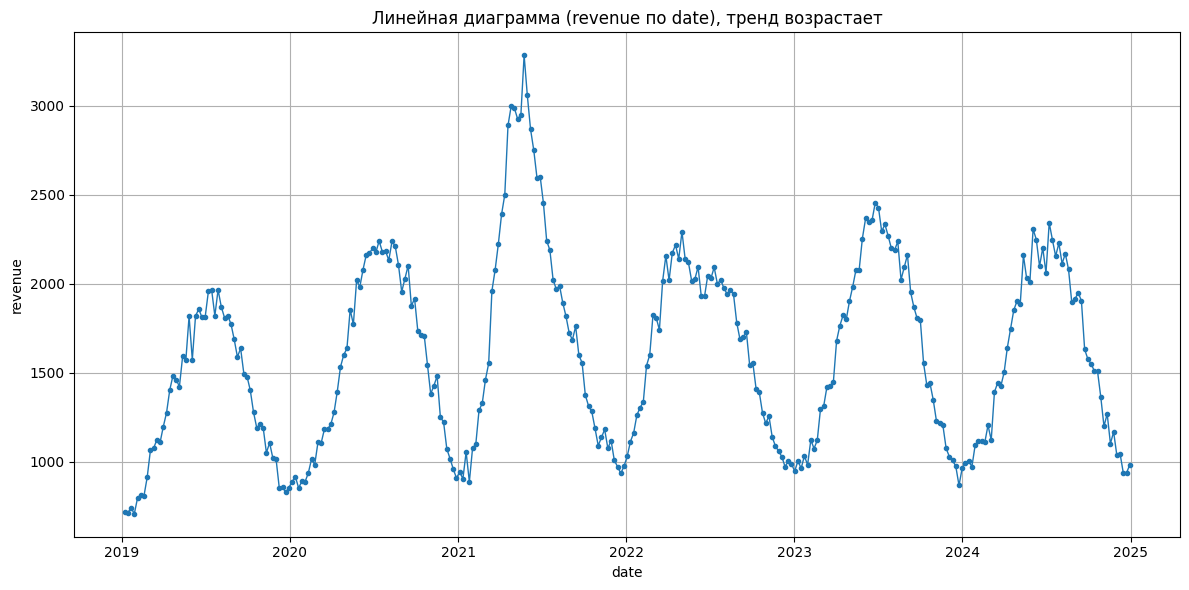

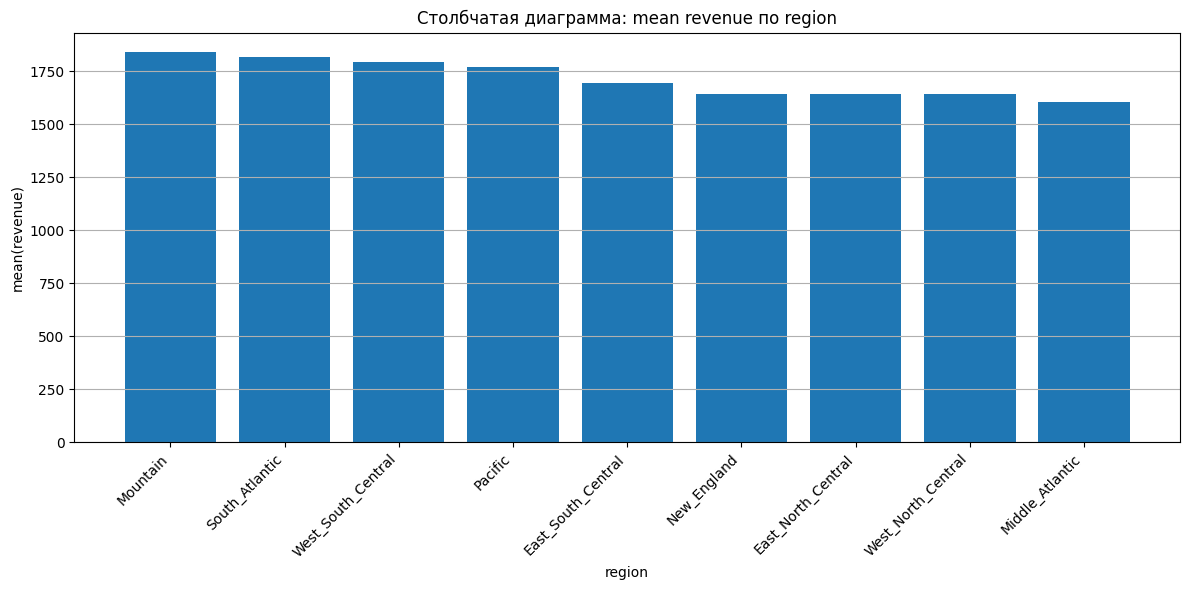

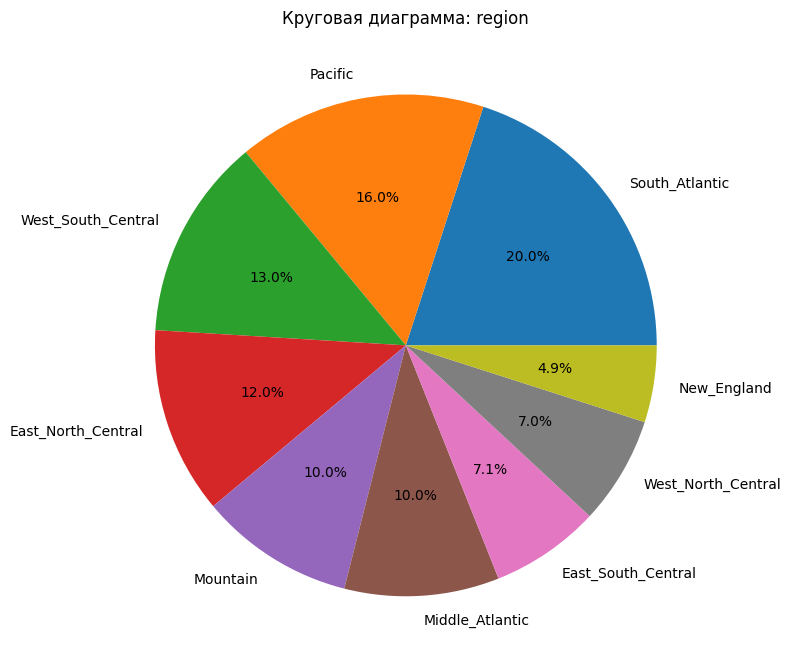

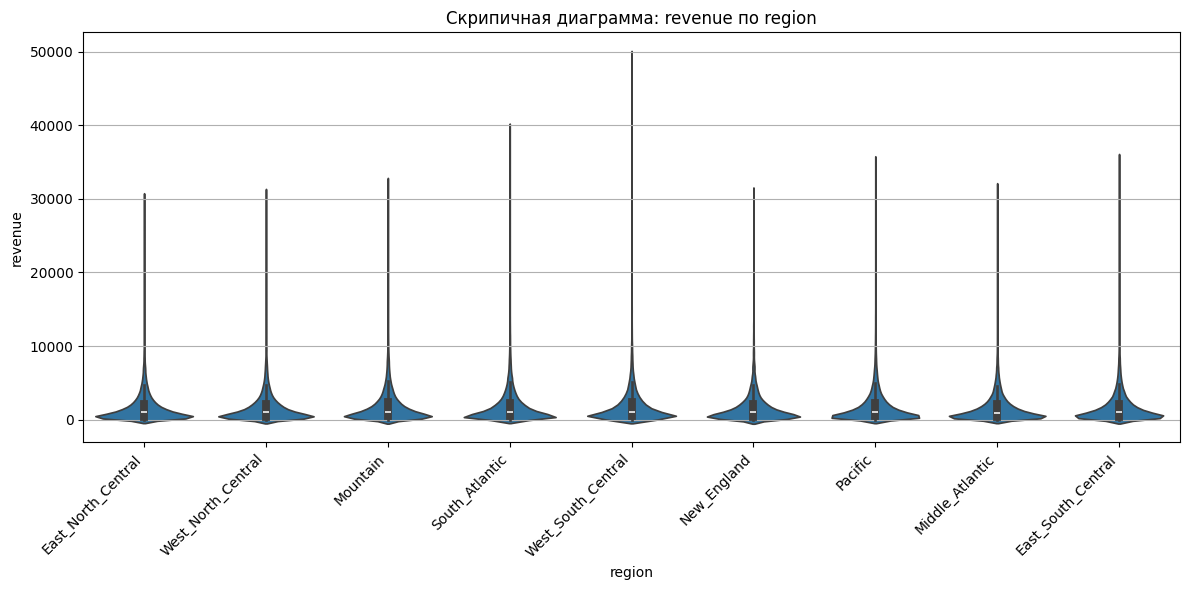

                              date           year          month  \
count                       340000  340000.000000  340000.000000   
unique                         NaN            NaN            NaN   
top                            NaN            NaN            NaN   
freq                           NaN            NaN            NaN   
mean    2022-01-19 01:44:46.616471    2021.543909       6.614615   
min            2019-01-07 00:00:00    2019.000000       1.000000   
25%            2020-07-20 00:00:00    2020.000000       4.000000   
50%            2022-02-14 00:00:00    2022.000000       7.000000   
75%            2023-07-17 00:00:00    2023.000000       9.000000   
max            2024-12-30 00:00:00    2024.000000      12.000000   
std                            NaN       1.711975       2.991934   

         week_of_year          region product_category       sku     channel  \
count   340000.000000          340000           340000    340000      340000   
unique            NaN  

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import lagrange, CubicSpline
from sklearn.metrics import mean_absolute_error, mean_squared_error


def load_data(filepath):
    return pd.read_csv(filepath)


def detect_columns(df):
    datetime_col = None
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            datetime_col = col
            break
    if datetime_col is None:
        for col in df.columns:
            if any(k in col.lower() for k in ('date', 'time', 'timestamp', 'datetime')):
                converted = pd.to_datetime(df[col], errors='coerce')
                if converted.notna().mean() > 0.9:
                    df[col] = converted
                    datetime_col = col
                    break
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != datetime_col]
    categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    return datetime_col, numeric_cols, categorical_cols


def preprocess_data(df, datetime_col=None, value_col=None):
    if datetime_col and datetime_col in df.columns:
        df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
        df = df.sort_values(datetime_col).reset_index(drop=True)
    if value_col and value_col in df.columns:
        df = df.dropna(subset=[value_col]).reset_index(drop=True)
    return df


def plot_line(df, x_col, y_col):
    plt.figure(figsize=(12, 6))
    plt.plot(df[x_col], df[y_col].to_numpy(), marker='.', linewidth=1)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True, which='both')
    if len(df) > 1:
        y = df[y_col].to_numpy(dtype=float)
        x = np.arange(len(y))
        trend = np.polyfit(x, y, 1)[0]
        direction = 'возрастает' if trend > 0 else 'убывает'
        plt.title(f'Линейная диаграмма ({y_col} по {x_col}), тренд {direction}')
    else:
        plt.title(f'Линейная диаграмма ({y_col} по {x_col})')
    plt.tight_layout()
    plt.show()


def plot_bar(df, cat_col, value_col, agg='mean', top_n=20):
    grouped = df.groupby(cat_col)[value_col].agg(agg).sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(12, 6))
    plt.bar(grouped.index.astype(str), grouped.to_numpy())
    plt.xlabel(cat_col)
    plt.ylabel(f'{agg}({value_col})')
    plt.title(f'Столбчатая диаграмма: {agg} {value_col} по {cat_col}')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


def plot_pie(df, cat_col, top_n=10):
    counts = df[cat_col].value_counts()
    if len(counts) > top_n:
        head = counts.head(top_n)
        other = counts.iloc[top_n:].sum()
        counts = pd.concat([head, pd.Series({'Другие': other})])
    plt.figure(figsize=(8, 8))
    counts.plot.pie(autopct='%1.1f%%')
    plt.title(f'Круговая диаграмма: {cat_col}')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()


def plot_violin(df, cat_col, value_col, top_n=10):
    top = df[cat_col].value_counts().head(top_n).index
    subset = df[df[cat_col].isin(top)]
    plt.figure(figsize=(12, 6))
    sns.violinplot(x=cat_col, y=value_col, data=subset)
    plt.xlabel(cat_col)
    plt.ylabel(value_col)
    plt.title(f'Скрипичная диаграмма: {value_col} по {cat_col}')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


def qualitative_analysis(df):
    print(df.describe(include='all'))
    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.shape[1] > 1:
        print(numeric_df.corr())
    else:
        print('Числовых столбцов меньше двух — матрица корреляций не строится.')


def thin_data(series):
    values = series.to_numpy(dtype=float, copy=True)
    values[1::2] = np.nan
    return pd.Series(values, index=series.index)


def fill_mean(series):
    return series.fillna(series.mean())


def fill_median(series):
    return series.fillna(series.median())


def fill_previous_3_mean(series):
    values = series.to_numpy(dtype=float, copy=True)
    for i in range(len(values)):
        if np.isnan(values[i]):
            window = values[max(0, i - 3):i]
            window = window[~np.isnan(window)]
            if len(window) > 0:
                values[i] = window.mean()
    return pd.Series(values, index=series.index)


def fill_lagrange(series):
    values = series.to_numpy(dtype=float, copy=True)
    known_mask = ~np.isnan(values)
    if known_mask.sum() < 2:
        return series
    x_all = np.arange(len(values))
    poly = lagrange(x_all[known_mask], values[known_mask])
    missing = np.isnan(values)
    values[missing] = poly(x_all[missing])
    return pd.Series(values, index=series.index)


def fill_cubic_spline(series):
    values = series.to_numpy(dtype=float, copy=True)
    known_mask = ~np.isnan(values)
    if known_mask.sum() < 4:
        return series
    x_all = np.arange(len(values))
    cs = CubicSpline(x_all[known_mask], values[known_mask])
    missing = np.isnan(values)
    values[missing] = cs(x_all[missing])
    return pd.Series(values, index=series.index)


def plot_imputation(original, thinned, filled_dict):
    plt.figure(figsize=(12, 6))
    plt.plot(original.index, original.to_numpy(), label='Оригинал', alpha=0.4, linewidth=1)
    plt.plot(thinned.index, thinned.to_numpy(), 'o', label='Известные (прореженные)', markersize=3)
    removed_mask = thinned.isna().to_numpy()
    plt.plot(original.index[removed_mask], original.to_numpy()[removed_mask], 'x',
             label='Отброшенные (реальные)', markersize=5, color='black')
    for name, filled in filled_dict.items():
        plt.plot(filled.index, filled.to_numpy(), label=name, linewidth=1)
    plt.xlabel('Индекс')
    plt.ylabel('Значение')
    plt.title('Восстановление пропущенных значений')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def detect_outliers_2_3_sigma(series):
    series = series.dropna()
    mean = series.mean()
    std = series.std()
    result = {}
    for k in (2, 3):
        lower = mean - k * std
        upper = mean + k * std
        result[f'{k}sigma'] = series[(series < lower) | (series > upper)]
    return result


def plot_box_violin(series):
    series = series.dropna()
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot(y=series)
    plt.title('Box-plot')
    plt.subplot(1, 2, 2)
    sns.violinplot(y=series)
    plt.title('Violin plot')
    plt.tight_layout()
    plt.show()


def create_artificial_missing(df, datetime_col, value_col, start, end):
    mask = (df[datetime_col] >= start) & (df[datetime_col] <= end)
    df.loc[mask, value_col] = np.nan
    return df


def calculate_metrics(real, predicted):
    real = np.asarray(real, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae = mean_absolute_error(real, predicted)
    rmse = np.sqrt(mean_squared_error(real, predicted))
    mask = real != 0
    if mask.any():
        mape = np.mean(np.abs((real[mask] - predicted[mask]) / real[mask])) * 100
    else:
        mape = np.nan
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


def plot_3d(df, x_col, y_col, z_col):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(df[x_col].to_numpy(), df[y_col].to_numpy(), df[z_col].to_numpy(), alpha=0.4)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)
    plt.title(f'Трёхмерный график: {x_col} / {y_col} / {z_col}')
    plt.tight_layout()
    plt.show()

def add_random_missing(df, value_col, fraction=0.1, mode='points',
                       block_size=5, n_blocks=None, seed=None):
    rng = np.random.default_rng(seed)
    df = df.copy()
    n = len(df)
    values = df[value_col].to_numpy(dtype=float, copy=True)

    if mode == 'points':
        k = int(n * fraction)
        idx = rng.choice(n, size=k, replace=False)
        values[idx] = np.nan

    elif mode == 'blocks':
        if n_blocks is None:
            n_blocks = max(1, int(n * fraction / block_size))
        for _ in range(n_blocks):
            start = rng.integers(0, max(1, n - block_size))
            values[start:start + block_size] = np.nan

    elif mode == 'interval':
        length = int(n * fraction)
        start = rng.integers(0, max(1, n - length))
        values[start:start + length] = np.nan

    else:
        raise ValueError(f'Неизвестный режим: {mode}')

    df[value_col] = values
    return df

def main():
    filepath = r'building_materials_transactions.csv'
    df = load_data(filepath)
    datetime_col, numeric_cols, categorical_cols = detect_columns(df)

    value_col = None
    for candidate in ('revenue', 'sales', 'amount', 'value', 'price', 'units'):
        if candidate in numeric_cols:
            value_col = candidate
            break
    if value_col is None and numeric_cols:
        value_col = numeric_cols[0]

    cat_col = None
    for candidate in ('region', 'category', 'product_category', 'channel', 'customer_type'):
        if candidate in categorical_cols:
            cat_col = candidate
            break
    if cat_col is None and categorical_cols:
        cat_col = categorical_cols[0]

    df = preprocess_data(df, datetime_col, value_col)

    if datetime_col and value_col:
        df_t = df.groupby(datetime_col)[value_col].mean().reset_index()
        df_t = df_t.sort_values(datetime_col).reset_index(drop=True)
        plot_line(df_t, datetime_col, value_col)
    elif value_col:
        tmp = df.reset_index(drop=True).copy()
        tmp['_index'] = tmp.index
        plot_line(tmp, '_index', value_col)

    if cat_col and value_col:
        plot_bar(df, cat_col, value_col)
        plot_pie(df, cat_col)
        plot_violin(df, cat_col, value_col)

    qualitative_analysis(df) #Корреляционный анализ

    print(f"Количество пропущенных значений: {df["revenue"].isna().sum()}")


if __name__ == '__main__':
    main()